In [ ]:
# Monte Carlo Dropout version
# visibility classification problem using other parameters
%tensorflow_version 2.x

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3aietf%3awg%3aoauth%3a2.0%3aoob&response_type=code&scope=email%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdocs.test%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.photos.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fpeopleapi.readonly

Enter your authorization code:
··········
Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import metrics

from google.colab import files

import tensorflow as tf

from tensorflow.keras.utils import to_categorical, plot_model

from tensorflow.keras.layers import Input, Dense, Reshape, Flatten, Multiply,\
    LSTM, Concatenate, Activation, RepeatVector, TimeDistributed, Conv1D, Add
from tensorflow.keras.models import Model, load_model

from tensorflow.keras import losses
from tensorflow.keras import backend as K

tf.test.gpu_device_name()
print(tf.__version__)

2.2.0


In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# Load the data
obs_data_vis = np.load('/content/gdrive/My Drive/Colab Notebooks/Visobs.npy', allow_pickle=True)
model_data_vis = np.load('/content/gdrive/My Drive/Colab Notebooks/Vismodel.npy', allow_pickle=True)

obs_data_T = np.load('/content/gdrive/My Drive/Colab Notebooks/Tobs.npy', allow_pickle=True)
model_data_T = np.load('/content/gdrive/My Drive/Colab Notebooks/Tmodel.npy', allow_pickle=True)

obs_data_Td = np.load('/content/gdrive/My Drive/Colab Notebooks/Tdobs.npy', allow_pickle=True)
model_data_Td = np.load('/content/gdrive/My Drive/Colab Notebooks/Tdmodel.npy', allow_pickle=True)

In [ ]:
# Max model visibility data is 9999 so truncate model vis to that
model_data_vis[model_data_vis > np.max(obs_data_vis)] = np.max(obs_data_vis) 

In [ ]:
# Bin the data
bins = [0, 150, 350, 600, 800, 1500, 3000, 5000, 10000]
obs_data_vis = pd.cut(obs_data_vis, bins, labels=[0,1,2,3,4,5,6,7])
model_binned = np.zeros(model_data_vis.shape)
for i in range(4):
  model_binned[i,:] = pd.cut(model_data_vis[i,:], bins, labels=[0,1,2,3,4,5,6,7])
model_data_vis = model_binned

In [ ]:
# Use the past_history nr of data to predict future_target nr of data
past_history = 24
future_target = 1

future_target_val = 1

In [ ]:
# Add obs data to model data
dataset = np.concatenate((model_data_vis, np.reshape(obs_data_vis,(1,-1))), axis=0)
dataset_vis = np.swapaxes(dataset,0,1)

dataset = np.concatenate((model_data_T, np.reshape(obs_data_T,(1,-1))), axis=0)
dataset_T = np.swapaxes(dataset,0,1)

dataset = np.concatenate((model_data_Td, np.reshape(obs_data_Td,(1,-1))), axis=0)
dataset_Td = np.swapaxes(dataset,0,1)

dataset_vis.shape

(27001, 5)

In [ ]:
# Split into training data
TRAIN_SPLIT = np.int(0.9*len(dataset_vis))
print(TRAIN_SPLIT)

24300


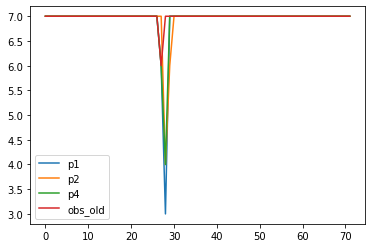

In [ ]:
# Plot part of data to make sure concatenation and normalization was successful
plt.plot(dataset_vis[:72,0])
plt.plot(dataset_vis[:72,1])
plt.plot(dataset_vis[:72,3])
plt.plot(dataset_vis[:72,4])
plt.legend(['p1','p2','p4','obs_old'])


In [ ]:
def multivariate_data(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
  data = []
  labels = []

  start_index = start_index + history_size
  if end_index is None:
    end_index = len(dataset) - target_size

  for i in range(start_index, end_index):
    #indices = range(i-history_size, i, step)
    indices = range(i-history_size, i+target_size, step)
    data.append(dataset[indices])

    if single_step:
      labels.append(target[i+target_size])
    else:
      labels.append(target[i:i+target_size])

  return np.array(data), np.array(labels)

In [ ]:
STEP = 1

# This is the visibility (target) dataset
x_train_vis, y_train_vis = multivariate_data(dataset_vis, dataset_vis[:,4], 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_val_vis, y_val_vis = multivariate_data(dataset_vis, dataset_vis[:,4],
                                             TRAIN_SPLIT, None, past_history,
                                             future_target_val, STEP)

# These are the auxiliary (T, Td) datasets
x_train_T, _ = multivariate_data(dataset_T, dataset_T[:,4], 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_val_T, _ = multivariate_data(dataset_T, dataset_T[:,4],
                                             TRAIN_SPLIT, None, past_history,
                                             future_target_val, STEP)

x_train_Td, _ = multivariate_data(dataset_Td, dataset_Td[:,4], 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_val_Td, _ = multivariate_data(dataset_Td, dataset_Td[:,4],
                                             TRAIN_SPLIT, None, past_history,
                                             future_target_val, STEP)


In [ ]:
# Now remove all cases where there has been constant (max) visibility
# idx = np.sum(x_train_vis[:,:,4], axis=1) != np.max(np.sum(x_train_vis[:,:,4], axis=1))
# idx_v = np.sum(x_val_vis[:,:,4], axis=1) != np.max(np.sum(x_val_vis[:,:,4], axis=1))

idx = np.sum(y_train_vis, axis=1) != np.max(np.sum(y_train_vis, axis=1))
idx_v = np.sum(y_val_vis, axis=1) != np.max(np.sum(y_val_vis, axis=1))

x_train_vis = x_train_vis[idx,]
y_train_vis = y_train_vis[idx,]
x_train_T = x_train_T[idx,]
x_train_Td = x_train_Td[idx,]

x_val_vis = x_val_vis[idx_v,]
y_val_vis = y_val_vis[idx_v,]
x_val_T = x_val_T[idx_v,]
x_val_Td = x_val_Td[idx_v,]

In [ ]:
# Set the future obs to the average of the model data
x_train_vis[:,past_history:,4] = np.round(np.average(x_train_vis[:,past_history:,0:4], axis=2))
x_val_vis[:,past_history:,4] = np.round(np.average(x_val_vis[:,past_history:,0:4], axis=2))

x_train_T[:,past_history:,4] = np.round(np.average(x_train_T[:,past_history:,0:4], axis=2))

x_train_Td[:,past_history:,4] = np.round(np.average(x_train_Td[:,past_history:,0:4], axis=2))

In [ ]:
# Using T-Td as feature
x_train_TTd = x_train_T-x_train_Td
x_val_TTd = x_val_T-x_val_Td

# Now standardize the data
x_train_TTd = (x_train_TTd-np.mean(x_train_TTd))/np.std(x_train_TTd)
x_val_TTd = (x_val_TTd-np.mean(x_val_TTd))/np.std(x_val_TTd)

In [ ]:
print(x_train_vis.shape)
print(y_train_vis.shape)

(1684, 25, 5)
(1684, 1)


In [ ]:
# Data shape
print ('Single window of past history : {}'.format(x_train_vis[0].shape))
print ('\n Target visibility to predict : {}'.format(y_train_vis[0].shape))

Single window of past history : (25, 5)

 Target visibility to predict : (1,)


In [ ]:
def wavenetBlock(filters, kernel_size, dilation_rate):
  def f(input_):
    residual = input_
    tanh_out = Conv1D(filters=filters, kernel_size=kernel_size, 
                    dilation_rate=dilation_rate, padding='causal',
                    activation='tanh')(input_)
    sigmoid_out = Conv1D(filters=filters, kernel_size=kernel_size, 
                    dilation_rate=dilation_rate, padding='causal',
                    activation='sigmoid')(input_)
    merged = Multiply()([tanh_out, sigmoid_out])
    skip_out = Conv1D(1,1, activation='relu', padding='causal')(merged)
    out = Add()([skip_out, residual])
    return out, skip_out
  return f                  

In [ ]:
input_shape = (past_history+future_target,5,)

in_vis = Input(shape=input_shape)
in_TTd = Input(shape=input_shape)

# Pass visibility and TTd through dense layer to get comparable magnitudes in data
b_vis = TimeDistributed(Dense(16, activation='relu'))(in_vis)
b_TTd = TimeDistributed(Dense(16, activation='relu'))(in_TTd)

# Now concatenate them
in_ = Concatenate()([b_vis, b_TTd])

# Wavenet model
A, B = wavenetBlock(64, 2, 2)(in_)
skip_connections = [B]
for i in range(3):
  A, B = wavenetBlock(64, 2, 2**(i+2))(A)
  skip_connections.append(B)
b = Add()(skip_connections)
b = Activation('relu')(b)
net = Conv1D(1, 1, activation='relu')(b)
net = Conv1D(1, 1)(net)
net = Flatten()(net)
out = Dense(8, activation='softmax')(net)

model = Model([in_vis, in_TTd], out)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', 
              metrics=['acc'])
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 25, 5)]      0                                            
__________________________________________________________________________________________________
input_2 (InputLayer)            [(None, 25, 5)]      0                                            
__________________________________________________________________________________________________
time_distributed (TimeDistribut (None, 25, 16)       96          input_1[0][0]                    
__________________________________________________________________________________________________
time_distributed_1 (TimeDistrib (None, 25, 16)       96          input_2[0][0]                    
______________________________________________________________________________________________

In [ ]:
EPOCHS = 50

multi_step_history = model.fit([x_train_vis, x_train_TTd], y_train_vis, batch_size=32,
                               validation_split=0.1, epochs=EPOCHS)

Epoch 1/50
48/48 [==============================] - 1s 25ms/step - loss: 2.0296 - acc: 0.5340 - val_loss: 1.9393 - val_acc: 0.6036
Epoch 2/50
48/48 [==============================] - 1s 11ms/step - loss: 1.8177 - acc: 0.5439 - val_loss: 1.6421 - val_acc: 0.6036
Epoch 3/50
48/48 [==============================] - 1s 11ms/step - loss: 1.5403 - acc: 0.5439 - val_loss: 1.3949 - val_acc: 0.6036
Epoch 4/50
48/48 [==============================] - 1s 11ms/step - loss: 1.3935 - acc: 0.5439 - val_loss: 1.3113 - val_acc: 0.6036
Epoch 5/50
48/48 [==============================] - 1s 11ms/step - loss: 1.3551 - acc: 0.5439 - val_loss: 1.2870 - val_acc: 0.6036
Epoch 6/50
48/48 [==============================] - 1s 11ms/step - loss: 1.3412 - acc: 0.5439 - val_loss: 1.2765 - val_acc: 0.6036
Epoch 7/50
48/48 [==============================] - 1s 11ms/step - loss: 1.3331 - acc: 0.5439 - val_loss: 1.2693 - val_acc: 0.6036
Epoch 8/50
48/48 [==============================] - 1s 11ms/step - loss: 1.3274 - a

In [ ]:
def plot_train_history(history, title):
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  epochs = range(len(loss))

  plt.figure()

  plt.plot(epochs, loss, 'b', label='Training loss')
  plt.plot(epochs, val_loss, 'r', label='Validation loss')
  plt.title(title)
  plt.legend()

  plt.show()

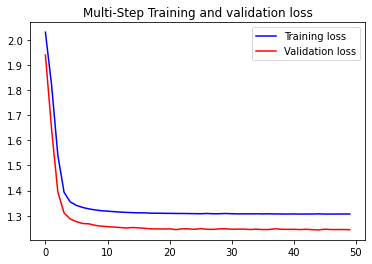

In [ ]:
plot_train_history(multi_step_history, 'Multi-Step Training and validation loss')

In [ ]:
from google.colab import files

Text(0, 0.5, 'class')

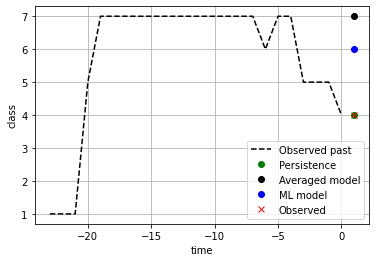

In [ ]:
# Plot some results
ix = np.random.randint(0, len(x_val_vis))

vis = np.expand_dims(x_val_vis[ix,], axis=0)
true_vis = np.expand_dims(y_val_vis[ix,], axis=0)
TTd = np.expand_dims(x_val_TTd[ix,], axis=0)

vis_pred = np.argmax(model([vis, TTd]), axis=1)

# This is the input observations
plt.plot(np.arange(-past_history+1, 1), vis[0,:past_history,4],'k--')

# Persitence prediction
plt.plot(np.arange(1, future_target_val+1), x_val_vis[ix, past_history-1, 4]*np.ones(future_target_val),'go')

# Averaged model prediction
plt.plot(np.arange(1, future_target_val+1), vis[0,past_history:,4],'ko')

# ML prediction
plt.plot(np.arange(1, future_target_val+1), vis_pred[0,],'bo')

# True observed future
plt.plot(np.arange(1, future_target+1), true_vis[0,],'rx')

plt.legend(['Observed past','Persistence','Averaged model','ML model','Observed']) 
plt.grid()
plt.xlabel('time')
plt.ylabel('class')

#plt.savefig("Case" + str(ix) + ".png")
#files.download("Case" + str(ix) + ".png")

#for i in range(runs):
#  plt.plot(np.arange(0, future_target), np.round(vis_prob[i,0,]),'r-.')

In [ ]:
# Now verify the model

n_val = len(x_val_vis)

pers = np.zeros((n_val, future_target))
aver = np.zeros((n_val, future_target))
ml = np.zeros((n_val, future_target))

for i in range(n_val):

  # 1) Persistence forecast
  pers[i,] = x_val_vis[i, past_history-1, 4]*np.ones(future_target)

  # 2) Averaged model forecast
  aver[i,] = x_val_vis[i,past_history:, 4]

  # 3) ML forecast
  vis = np.expand_dims(x_val_vis[i,], axis=0)
  TTd = np.expand_dims(x_val_TTd[i,], axis=0)
  ml[i,] = np.argmax(model([vis, TTd]), axis=1)

In [ ]:
# Forecast verification
acc_score_pers = np.zeros(future_target)
acc_score_aver = np.zeros(future_target)
acc_score_ml = np.zeros(future_target)

mae_pers = np.zeros(future_target)
mae_aver = np.zeros(future_target)
mae_ml = np.zeros(future_target)

prec_score_pers = np.zeros((future_target, 8))
prec_score_aver = np.zeros((future_target, 8))
prec_score_ml = np.zeros((future_target, 8))

recall_score_pers = np.zeros((future_target, 8))
recall_score_aver = np.zeros((future_target, 8))
recall_score_ml = np.zeros((future_target, 8))

fbeta_score_pers = np.zeros((future_target, 8))
fbeta_score_aver = np.zeros((future_target, 8))
fbeta_score_ml = np.zeros((future_target, 8))

support_score_pers = np.zeros((future_target, 8))
support_score_aver = np.zeros((future_target, 8))
support_score_ml = np.zeros((future_target, 8))

confusion_matrix_pers = np.zeros((future_target, 8, 8))
confusion_matrix_aver = np.zeros((future_target, 8, 8))
confusion_matrix_ml = np.zeros((future_target, 8, 8))

labels = np.uint32(['0','1','2','3','4','5','6','7'])

for i in range(future_target):
  
  # Forecasts at hour i
  y_pers = pers[:,i]
  y_aver = aver[:,i]
  y_ml = ml[:,i]

  # True value at hour i
  y_true = y_val_vis[:,i]

  confusion_matrix_pers[i,] = metrics.confusion_matrix(y_true, y_pers, labels=labels)
  confusion_matrix_aver[i,] = metrics.confusion_matrix(y_true, y_aver, labels=labels)
  confusion_matrix_ml[i,] = metrics.confusion_matrix(y_true, y_ml, labels=labels)

  #print(metrics.precision_recall_fscore_support(y_true, y_pers, labels=labels))
  prec_score_pers[i, ], recall_score_pers[i, ], fbeta_score_pers[i, ], support_score_pers[i, ] = metrics.precision_recall_fscore_support(y_true, y_pers, labels=labels)
  prec_score_aver[i, ], recall_score_aver[i, ], fbeta_score_aver[i, ], support_score_aver[i, ] = metrics.precision_recall_fscore_support(y_true, y_aver, labels=labels)
  prec_score_ml[i, ], recall_score_ml[i, ], fbeta_score_ml[i, ], support_score_ml[i, ] = metrics.precision_recall_fscore_support(y_true, y_ml, labels=labels)

  # Accuracy scores and mean absolute error
  acc_score_pers[i] = metrics.accuracy_score(y_true, y_pers) 
  acc_score_aver[i] = metrics.accuracy_score(y_true, y_aver) 
  acc_score_ml[i] = metrics.accuracy_score(y_true, y_ml) 

  mae_pers[i] = metrics.mean_absolute_error(y_true, y_pers) 
  mae_aver[i] = metrics.mean_absolute_error(y_true, y_aver) 
  mae_ml[i] = metrics.mean_absolute_error(y_true, y_ml) 

/usr/local/lib/python3.6/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.6/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
# Compute PC, bias and POD from confusion matrices
PC_pers = np.zeros(future_target)
PC_aver = np.zeros(future_target)
PC_ml = np.zeros(future_target)

Bias_pers = np.zeros((future_target, 8))
Bias_aver = np.zeros((future_target, 8))
Bias_ml = np.zeros((future_target, 8))

POD_pers = np.zeros((future_target, 8))
POD_aver = np.zeros((future_target, 8))
POD_ml = np.zeros((future_target, 8))

for i in range(future_target):

  # Proportion correct
  PC_pers[i] = np.trace(confusion_matrix_pers[i,])/n_val
  PC_aver[i] = np.trace(confusion_matrix_aver[i,])/n_val
  PC_ml[i] = np.trace(confusion_matrix_ml[i,])/n_val

  # Bias and POD
  for j in range(8):
    Bias_pers[i,j] = np.sum(confusion_matrix_pers[i,j,:])/np.sum(confusion_matrix_pers[i,:,j])
    Bias_aver[i,j] = np.sum(confusion_matrix_aver[i,j,:])/np.sum(confusion_matrix_aver[i,:,j])
    Bias_ml[i,j] = np.sum(confusion_matrix_ml[i,j,:])/np.sum(confusion_matrix_ml[i,:,j]) 

    POD_pers[i,j] = confusion_matrix_pers[i,j,j]/np.sum(confusion_matrix_pers[i,:,j])
    POD_aver[i,j] = confusion_matrix_aver[i,j,j]/np.sum(confusion_matrix_aver[i,:,j])
    POD_ml[i,j] = confusion_matrix_ml[i,j,j]/np.sum(confusion_matrix_ml[i,:,j])

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:23: RuntimeWarning: invalid value encountered in double_scalars
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:25: RuntimeWarning: invalid value encountered in double_scalars
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:27: RuntimeWarning: invalid value encountered in double_scalars
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:29: RuntimeWarning: invalid value encountered in double_scalars
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:25: RuntimeWarning: divide by zero encountered in double_scalars


In [ ]:
np.set_printoptions(precision=1)
for i in range(future_target):
  print('PC correct at forecast hour {} (persistence, averaged model, ML model): {}, {}, {}'.format(i+1, PC_pers[i], PC_aver[i], PC_ml[i]))
  print('Bias at forecast hour {} (pers): {}'.format(i+1, Bias_pers[i,]))
  print('Bias at forecast hour {} (aver): {}'.format(i+1, Bias_aver[i,]))
  print('Bias at forecast hour {} (ml  ): {}'.format(i+1, Bias_ml[i,]))
  print('POD at forecast hour {} (pers): {}'.format(i+1, POD_pers[i,]))
  print('POD at forecast hour {} (aver): {}'.format(i+1, POD_aver[i,]))
  print('POD at forecast hour {} (ml  ): {}\n'.format(i+1, POD_ml[i,]))

PC correct at forecast hour 1 (persistence, averaged model, ML model): 0.40540540540540543, 0.09266409266409266, 0.3745173745173745
Bias at forecast hour 1 (pers): [nan 1.  1.  1.  1.  1.2 1.5 0. ]
Bias at forecast hour 1 (aver): [0.  2.  1.9 1.6 1.  3.  3.7 0. ]
Bias at forecast hour 1 (ml  ): [nan inf inf inf inf inf 0.4 nan]
POD at forecast hour 1 (pers): [nan 0.7 0.6 0.3 0.3 0.4 0.6 0. ]
POD at forecast hour 1 (aver): [0.  0.2 0.2 0.1 0.1 0.1 0.5 0. ]
POD at forecast hour 1 (ml  ): [nan nan nan nan nan nan 0.4 nan]



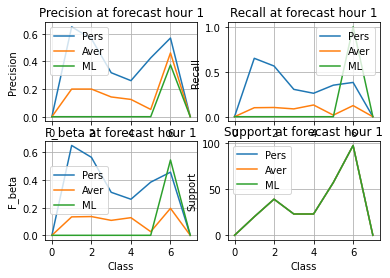

In [ ]:
# Plot scores
for i in range(future_target):

  plt.subplot(221)
  plt.plot(labels, prec_score_pers[i,])
  plt.plot(labels, prec_score_aver[i,])
  plt.plot(labels, prec_score_ml[i,])
  plt.grid()
  plt.xlabel('Class')
  plt.ylabel('Precision')
  plt.title('Precision at forecast hour {}'.format(i+1))
  plt.legend(['Pers','Aver','ML'])

  plt.subplot(222)
  plt.plot(labels, recall_score_pers[i,])
  plt.plot(labels, recall_score_aver[i,])
  plt.plot(labels, recall_score_ml[i,])
  plt.grid()
  plt.xlabel('Class')
  plt.ylabel('Recall')
  plt.title('Recall at forecast hour {}'.format(i+1))
  plt.legend(['Pers','Aver','ML'])

  plt.subplot(223)
  plt.plot(labels, fbeta_score_pers[i,])
  plt.plot(labels, fbeta_score_aver[i,])
  plt.plot(labels, fbeta_score_ml[i,])
  plt.grid()
  plt.xlabel('Class')
  plt.ylabel('F_beta')
  plt.title('F_beta at forecast hour {}'.format(i+1))
  plt.legend(['Pers','Aver','ML'])

  plt.subplot(224)
  plt.plot(labels, support_score_pers[i,])
  plt.plot(labels, support_score_aver[i,])
  plt.plot(labels, support_score_ml[i,])
  plt.grid()
  plt.xlabel('Class')
  plt.ylabel('Support')
  plt.title('Support at forecast hour {}'.format(i+1))
  plt.legend(['Pers','Aver','ML'])
  

  plt.show()



In [ ]:
print("Acuracy scores persistence: {}".format(acc_score_pers))
print("Acuracy scores average model: {}".format(acc_score_aver))
print("Acuracy scores ML model: {}\n".format(acc_score_ml))

print("MAE persistence: {}".format(mae_pers))
print("MAE average model: {}".format(mae_aver))
print("MAE ML model: {}".format(mae_ml))

Acuracy scores persistence: [0.4]
Acuracy scores average model: [0.1]
Acuracy scores ML model: [0.4]

MAE persistence: [0.9]
MAE average model: [2.]
MAE ML model: [1.7]


In [ ]:
#plot_model(model, to_file='model.png')
#files.download("model.png")

In [ ]:
# 256 / 256-256 -> 930.6428131656721
# 128 / 128-128 -> 894.5840283993166
# 64 / 64-64 -> 906.9504097113386
# 64 / 128-128 -> 860.8121605882188

In [ ]:
#i = np.random.randint(0, len(x_val_vis))
#plt.plot(np.arange(0, past_history), x_val_vis[i,:past_history,4])
#plt.plot(np.arange(past_history, past_history+future_target), y_val_vis[i,])